In [5]:
# Load directly via raw URL (No file downloading required)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ==========================================
# 2. DATA CLEANING & PREPROCESSING
# ==========================================

# 1. Drop unique identifiers that carry no predictive power
df.drop('customerID', axis=1, inplace=True)

# 2. Fix missing/empty values in TotalCharges
# TotalCharges contains whitespace strings " " -> convert to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Impute missing values with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 3. Drop duplicate rows if present
df.drop_duplicates(inplace=True)

# 4. Encode Target Variable (Churn: Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. One-Hot Encoding for categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Preprocessed Dataset Shape:", df_encoded.shape)
print("Missing values remaining:", df_encoded.isnull().sum().sum())
df_encoded.head()

Preprocessed Dataset Shape: (7021, 31)
Missing values remaining: 0


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


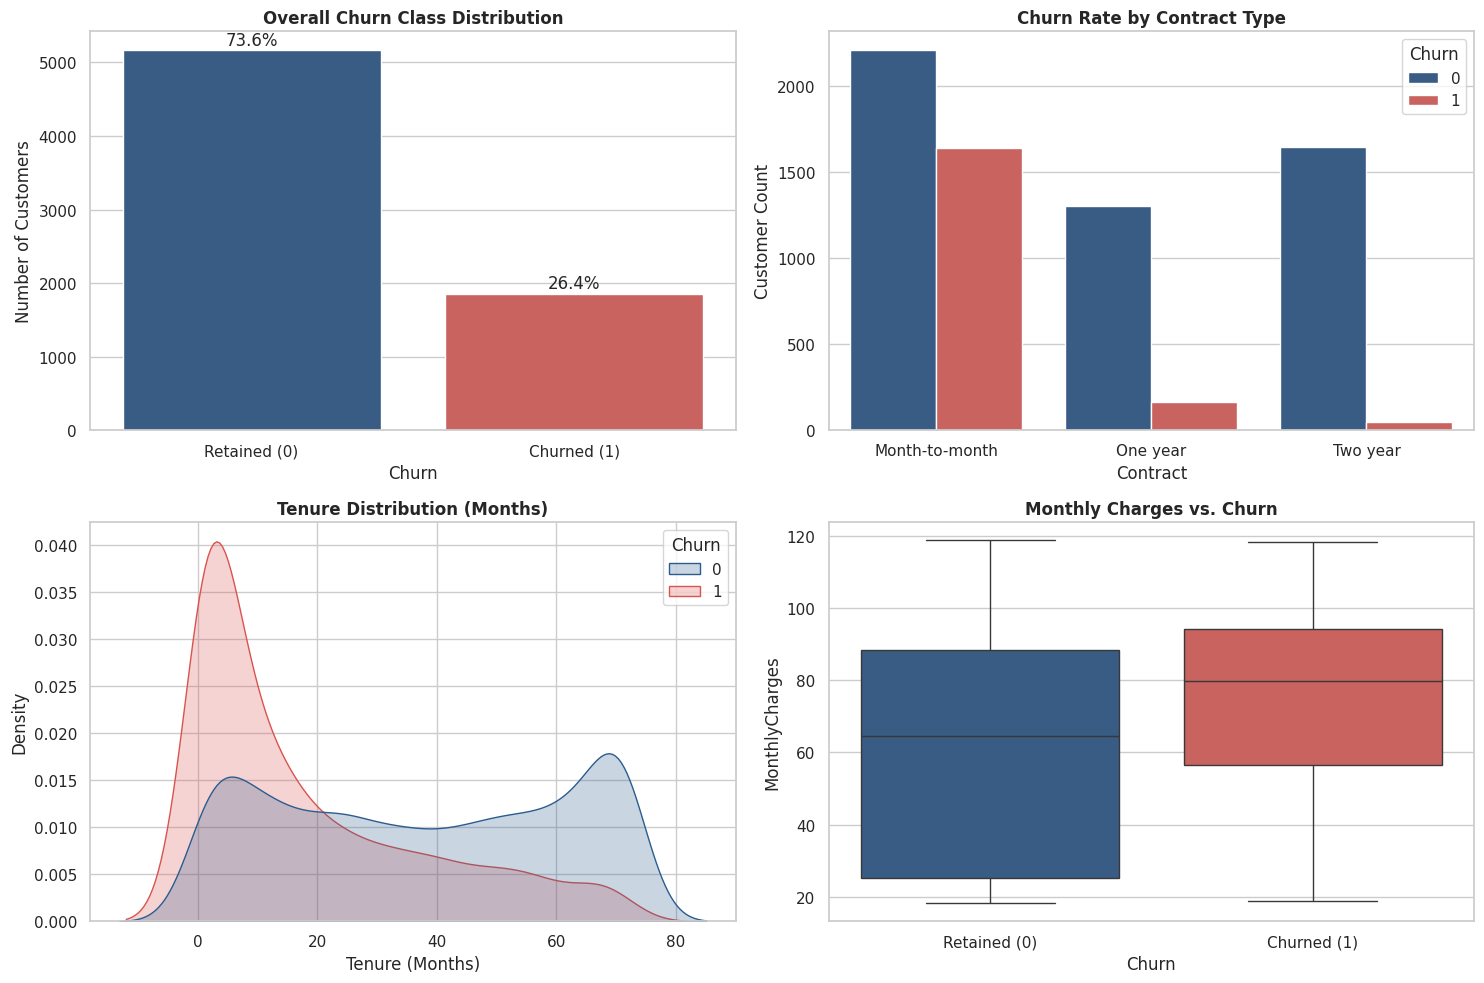

=== Key EDA Insights ===
Overall Churn Rate: 26.45%

Churn Rate by Contract Type:
Contract
Month-to-month    42.64
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [7]:
# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Set overall plot aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Create a figure layout with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Target Distribution (Churn Rate)
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=['#2b5c8f', '#d9534f'])
axes[0, 0].set_title('Overall Churn Class Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0, 0].set_ylabel('Number of Customers')

# Add percentage annotations on bars
total = len(df)
for p in axes[0, 0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    axes[0, 0].annotate(percentage, (x, y), ha='center', va='center')

# 2. Churn by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0, 1], palette=['#2b5c8f', '#d9534f'])
axes[0, 1].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Customer Count')

# 3. Tenure Distribution by Churn Status
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, 
            palette=['#2b5c8f', '#d9534f'], shade=True, ax=axes[1, 0])
axes[1, 0].set_title('Tenure Distribution (Months)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tenure (Months)')

# 4. Monthly Charges Distribution by Churn Status
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 1], palette=['#2b5c8f', '#d9534f'])
axes[1, 1].set_title('Monthly Charges vs. Churn', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

# Key Statistical Insights
print("=== Key EDA Insights ===")
print(f"Overall Churn Rate: {df['Churn'].mean() * 100:.2f}%")
print("\nChurn Rate by Contract Type:")
print(df.groupby('Contract')['Churn'].mean().round(4) * 100)

In [8]:
# ==========================================
# 4. DATA SPLITTING, SCALING & SMOTE RESAMPLING
# ==========================================

# 1. Separate Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 2. Stratified Train-Test Split (80% Train, 20% Test)
# Stratify ensures the class distribution (26.5% churn) is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Feature Scaling
# Scale continuous numerical features to prevent distance-based models from being skewed
scaler = StandardScaler()

# Fit only on training data, then transform both train and test sets
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 4. Handle Class Imbalance using SMOTE (Training Set Only)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Output summary
print("=== Train/Test Split & Resampling Summary ===")
print(f"Original Training Set shape : {X_train.shape}")
print(f"Test Set shape             : {X_test.shape}")
print(f"Original Class Balance (y_train):\n{y_train.value_counts()}")
print(f"\nResampled Class Balance (SMOTE y_train_res):\n{y_train_res.value_counts()}")

=== Train/Test Split & Resampling Summary ===
Original Training Set shape : (5616, 30)
Test Set shape             : (1405, 30)
Original Class Balance (y_train):
Churn
0    4131
1    1485
Name: count, dtype: int64

Resampled Class Balance (SMOTE y_train_res):
Churn
1    4131
0    4131
Name: count, dtype: int64


In [9]:
# ==========================================
# 5. MODEL TRAINING & PERFORMANCE COMPARISON
# ==========================================

# 1. Initialize Classification Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

# 2. Train and Evaluate Each Model
for name, model in models.items():
    # Train model on SMOTE-resampled training data
    model.fit(X_train_res, y_train_res)
    
    # Predict on unseen scaled test set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

# 3. Create & Display Model Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)

print("==================================================")
print("       MODEL PERFORMANCE COMPARISON TABLE         ")
print("==================================================")
print(comparison_df.to_string(index=False))

       MODEL PERFORMANCE COMPARISON TABLE         
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.7452     0.5126  0.7661    0.6142
            XGBoost    0.7786     0.5840  0.5699    0.5769
      Random Forest    0.7779     0.5843  0.5591    0.5714


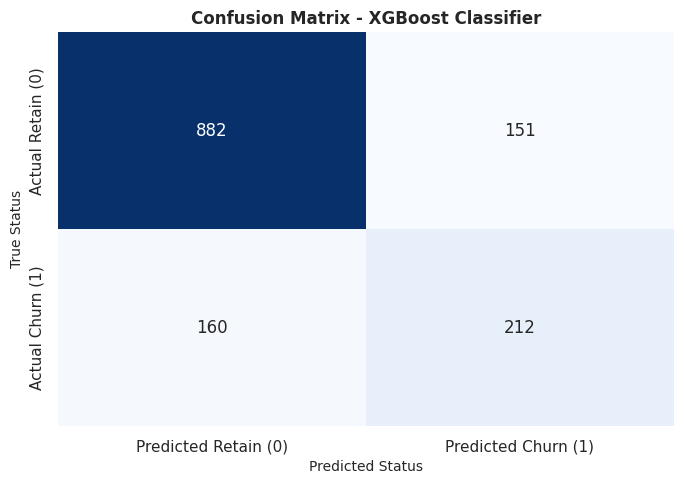

       CLASSIFICATION REPORT (XGBOOST)            
              precision    recall  f1-score   support

Retained (0)       0.85      0.85      0.85      1033
 Churned (1)       0.58      0.57      0.58       372

    accuracy                           0.78      1405
   macro avg       0.72      0.71      0.71      1405
weighted avg       0.78      0.78      0.78      1405



In [10]:
# ==========================================
# 6. DETAILED EVALUATION OF BEST MODEL (XGBoost)
# ==========================================

# 1. Select the top-performing model
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test_scaled)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['Predicted Retain (0)', 'Predicted Churn (1)'],
    yticklabels=['Actual Retain (0)', 'Actual Churn (1)']
)
plt.title('Confusion Matrix - XGBoost Classifier', fontsize=12, fontweight='bold')
plt.ylabel('True Status', fontsize=10)
plt.xlabel('Predicted Status', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Print Detailed Classification Report
print("==================================================")
print("       CLASSIFICATION REPORT (XGBOOST)            ")
print("==================================================")
print(classification_report(y_test, y_pred_best, target_names=['Retained (0)', 'Churned (1)']))

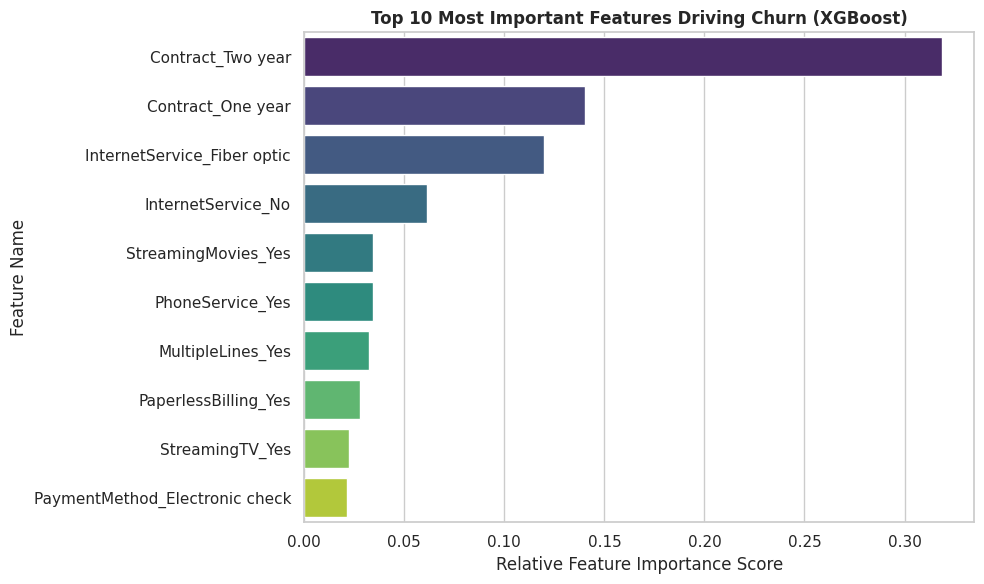


      BUSINESS RETENTION STRATEGY RECOMMENDATIONS

1. CONTRACT STRUCTURE:
   - Month-to-month contract holders show the highest risk of churn.
   - Recommendation: Offer targeted 10–15% bill discounts or perks for converting 
     to 1-year or 2-year contracts.

2. INTERNET SERVICE TYPE:
   - Fiber Optic subscribers exhibit disproportionately high churn compared to DSL.
   - Recommendation: Conduct service stability audits and offer introductory competitive 
     pricing to improve perceived value.

3. TENURE & ONBOARDING:
   - Early tenure (<12 months) carries the highest customer loss rate.
   - Recommendation: Implement a proactive 90-day customer onboarding sequence with 
     dedicated technical support checks.

4. PAYMENT METHODS:
   - Electronic check users churn at a significantly higher rate than auto-pay users.
   - Recommendation: Incentivize automatic bank transfers or credit card auto-pay with 
     a small one-time monthly billing credit.



In [11]:
# ==========================================
# 7. FEATURE IMPORTANCE & BUSINESS RECOMMENDATIONS
# ==========================================

# 1. Extract Feature Importances from XGBoost
importances = best_model.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feat_importances.head(10).values, 
    y=feat_importances.head(10).index, 
    palette='viridis'
)
plt.title('Top 10 Most Important Features Driving Churn (XGBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Feature Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# 2. Key Business Insights & Strategic Recommendations
print("""
==================================================
      BUSINESS RETENTION STRATEGY RECOMMENDATIONS
==================================================

1. CONTRACT STRUCTURE:
   - Month-to-month contract holders show the highest risk of churn.
   - Recommendation: Offer targeted 10–15% bill discounts or perks for converting 
     to 1-year or 2-year contracts.

2. INTERNET SERVICE TYPE:
   - Fiber Optic subscribers exhibit disproportionately high churn compared to DSL.
   - Recommendation: Conduct service stability audits and offer introductory competitive 
     pricing to improve perceived value.

3. TENURE & ONBOARDING:
   - Early tenure (<12 months) carries the highest customer loss rate.
   - Recommendation: Implement a proactive 90-day customer onboarding sequence with 
     dedicated technical support checks.

4. PAYMENT METHODS:
   - Electronic check users churn at a significantly higher rate than auto-pay users.
   - Recommendation: Incentivize automatic bank transfers or credit card auto-pay with 
     a small one-time monthly billing credit.
""")